# Prodigy InfoTech — Data Science Internship
## Task 03: Decision Tree Classifier

**Objective:** Build a decision tree classifier to predict whether a customer will subscribe to a product/service based on demographic and behavioral information.

This project uses the UCI Bank Marketing dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import urllib.request, zipfile, io
url='https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'
with urllib.request.urlopen(url) as r: data=io.BytesIO(r.read())
with zipfile.ZipFile(data) as z:
    with z.open('bank-additional/bank-additional-full.csv') as f:
        df=pd.read_csv(f,sep=';')
print('Dataset shape:',df.shape)
display(df.head())

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print(df.columns.tolist())
print('\nTarget distribution:')
display(df['y'].value_counts())
print('\nMissing values:')
display(df.isnull().sum().sort_values(ascending=False).head())

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target distribution:


y
no     36548
yes     4640
Name: count, dtype: int64


Missing values:


age          0
job          0
marital      0
education    0
default      0
dtype: int64

## Prepare the data

`y` is the target. `duration` is excluded because it is only known after a call and would not be available for a pre-call prediction.

In [4]:
X=df.drop(columns=['y','duration'])
y=df['y'].map({'no':0,'yes':1})
cat=X.select_dtypes(include=['object']).columns.tolist()
num=X.select_dtypes(exclude=['object']).columns.tolist()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
pre=ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore'),cat),('num','passthrough',num)])
model=DecisionTreeClassifier(max_depth=5,random_state=42,class_weight='balanced')
pipeline=Pipeline([('preprocessor',pre),('classifier',model)])
pipeline.fit(X_train,y_train)
print('Model trained successfully.')

C:\Users\Dikshit\AppData\Local\Temp\ipykernel_24604\3029777088.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat=X.select_dtypes(include=['object']).columns.tolist()


Model trained successfully.


In [5]:
y_pred=pipeline.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test,y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test,y_pred,target_names=['No Purchase','Purchase']))

Accuracy: 0.8511

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.95      0.88      0.91      7310
    Purchase       0.40      0.61      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.75      0.70      8238
weighted avg       0.88      0.85      0.86      8238



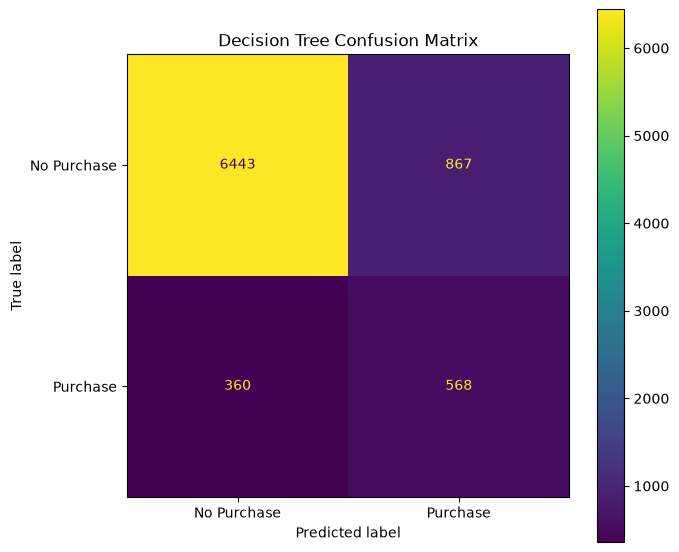

In [6]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Purchase','Purchase'])
fig,ax=plt.subplots(figsize=(7,6)); disp.plot(ax=ax); plt.title('Decision Tree Confusion Matrix'); plt.tight_layout(); plt.show()

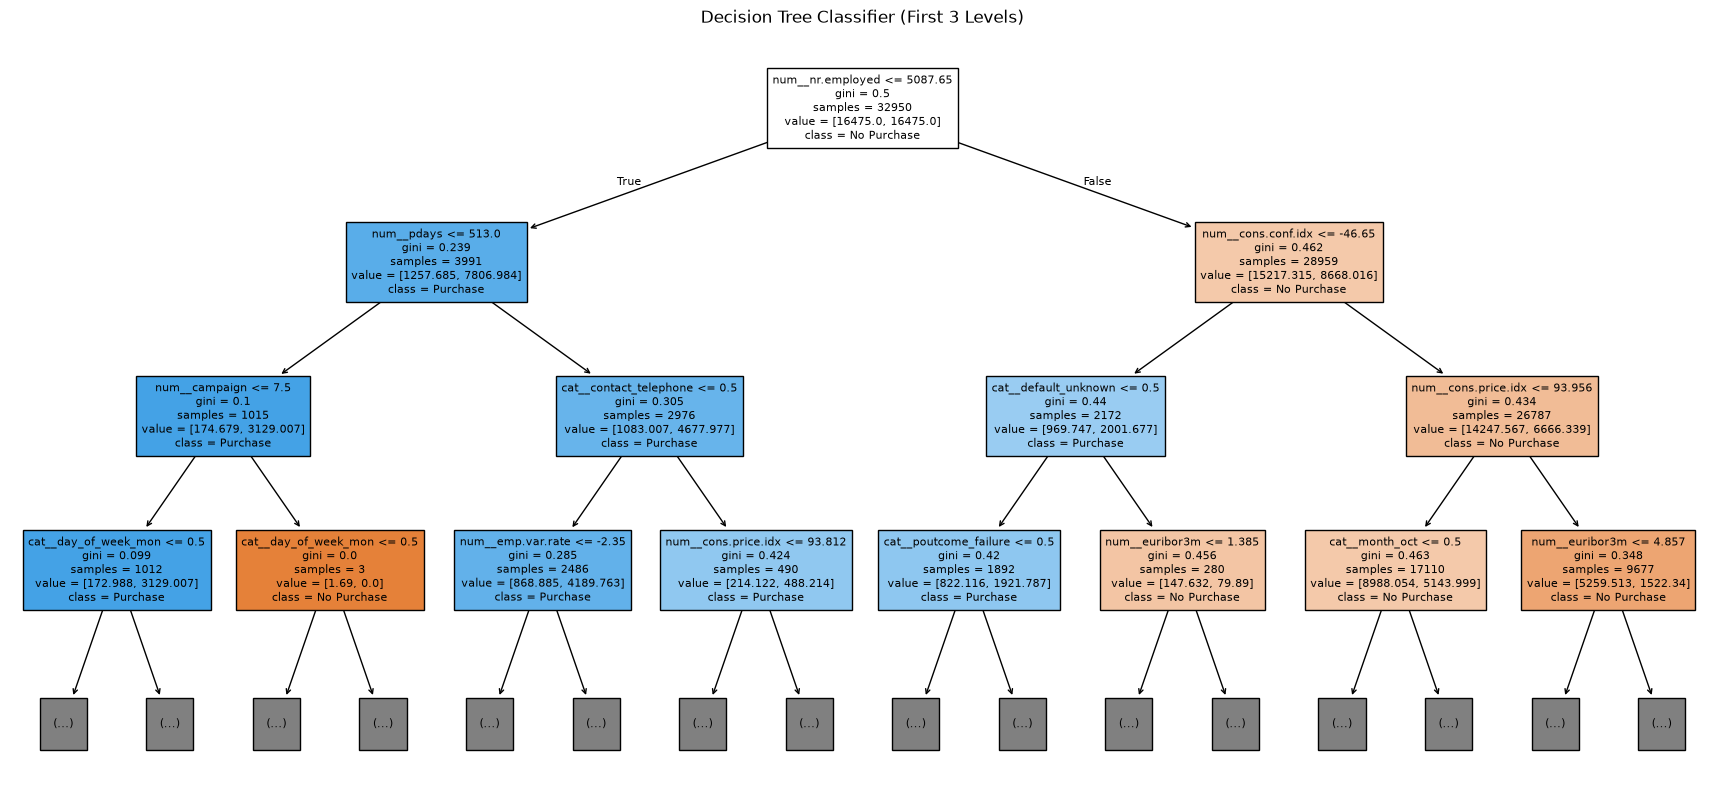

In [7]:
features=pipeline.named_steps['preprocessor'].get_feature_names_out()
tree=pipeline.named_steps['classifier']
plt.figure(figsize=(22,10))
plot_tree(tree,feature_names=features,class_names=['No Purchase','Purchase'],filled=True,max_depth=3,fontsize=8)
plt.title('Decision Tree Classifier (First 3 Levels)'); plt.show()

## Conclusion

The Decision Tree classifier predicts whether a customer subscribes to a term deposit. Categorical variables are one-hot encoded, the data is split into training and test sets, and the model is evaluated with accuracy, a classification report, and a confusion matrix. Because the target classes are imbalanced, accuracy should be considered together with the other metrics.